# Notebook 2 — Implementação de Métricas de Drift: KS, PSI, KL e JS

## Aula 2: Detecção Estatística de Drift de Dados

### Objetivos
- Implementar e aplicar o **teste Kolmogorov-Smirnov (KS)** para features contínuas
- Calcular o **PSI (Population Stability Index)** com binning e log-ratio
- Calcular as divergências **Kullback-Leibler (KL)** e **Jensen-Shannon (JS)**
- Aplicar o **teste Qui-quadrado (χ²)** para features categóricas
- Interpretar conjuntamente os resultados de todos os métodos

### Teoria-Chave (Documento 04)

> **Métricas de dissimilaridade** produzem um número indicando o quanto as distribuições
> se afastaram. Os **testes de hipótese** indicam se essa diferença é estatisticamente
> significativa.
>
> "Uma boa estratégia de monitoramento de drift inclui ambos: screening contínuo com
> métricas de divergência e confirmação com testes estatísticos formais."
>
> — Seção *Saiba Mais*, Documento da Aula 2

### Vídeos Relacionados
- **Vídeo 2** — Métricas de Dissimilaridade: KL, JS e PSI (18 min)
- **Vídeo 3** — Detectando Drift com KS e PSI em Python (20 min)

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon

# Adiciona diretório raiz da aula ao path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import DriftDetector, DriftResult, DriftReport
from src.evaluation import (
    plot_distribution_comparison,
    plot_cdf_comparison,
    plot_psi_bars,
    plot_drift_heatmap,
    generate_drift_summary,
)

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga dos Dados

Carregamos o dataset gerado no Notebook 1, separando referência e produção.

In [2]:
# Carregar dataset
preprocessor = DataPreprocessor(seed=42, n_samples=5000)
data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if not data_path.exists():
    preprocessor.generate_and_save(str(data_path))

ref_data, prod_data = preprocessor.load_data(str(data_path))
_, numerical_cols, categorical_cols = preprocessor.prepare_features(ref_data)

print(f"Referência: {len(ref_data)} | Produção: {len(prod_data)}")
print(f"Numéricas: {numerical_cols}")
print(f"Categóricas: {categorical_cols}")

Referência: 5000 | Produção: 5000
Numéricas: ['idade', 'renda_mensal', 'score_credito', 'tempo_emprego', 'valor_emprestimo', 'taxa_utilizacao_credito', 'num_parcelas_atraso']
Categóricas: ['tipo_residencia', 'categoria_risco']


## 2. Teste de Kolmogorov-Smirnov (KS)

> "O teste KS compara duas distribuições contínuas calculando a maior diferença
> entre suas funções de distribuição acumulada (CDFs). A estatística KS, geralmente
> denotada por D, varia de 0 a 1."
>
> — Seção *Testes estatísticos de hipóteses*, Documento da Aula 2

$$D = \sup_x |F_{\text{ref}}(x) - F_{\text{prod}}(x)|$$

Se o **p-valor < 0.05**, rejeitamos H₀ (distribuições idênticas) → **drift detectado**.

### 2.1 Implementação Manual (Snippet 1 do Hands On)

In [3]:
# Snippet 1 do Hands On: Teste KS para a feature 'idade'
# Conforme o Documento da Aula 2
dados_ref = ref_data["idade"].values
dados_novos = prod_data["idade"].values

estatistica, p_valor = stats.ks_2samp(dados_ref, dados_novos)
print(f"Estatística KS: {estatistica:.4f}")
print(f"p-valor: {p_valor:.3e}")
print(f"\nDrift detectado? {'SIM ✓' if p_valor < 0.05 else 'NÃO ✗'}")
print(f"(p-valor {'<' if p_valor < 0.05 else '≥'} 0.05)")

Estatística KS: 0.4344
p-valor: 0.000e+00

Drift detectado? SIM ✓
(p-valor < 0.05)


### 2.2 Visualização das CDFs (Teste KS Visual)

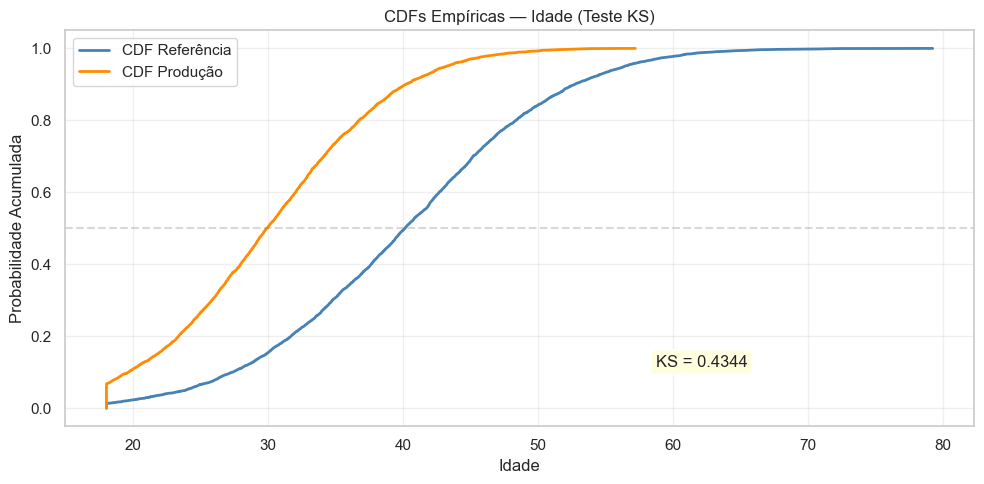

In [4]:
# CDFs empíricas — a distância máxima entre elas é a estatística KS
fig = plot_cdf_comparison(
    ref_data["idade"].values,
    prod_data["idade"].values,
    feature_name="Idade",
    ks_statistic=estatistica,
)
plt.show()

### 2.3 KS Test em Todas as Features Numéricas

In [5]:
# Aplicar KS test em todas as features numéricas usando DriftDetector
detector = DriftDetector(alpha=0.05)

print(f"{'Feature':<30} {'Estatística KS':>15} {'p-valor':>15} {'Drift?':>10}")
print("-" * 75)

for col in numerical_cols:
    result = detector.ks_test(
        ref_data[col].values, prod_data[col].values, feature_name=col
    )
    symbol = "✓ SIM" if result.drift_detected else "✗ NÃO"
    print(f"{result.feature_name:<30} {result.statistic:>15.4f} {result.p_value:>15.3e} {symbol:>10}")

Feature                         Estatística KS         p-valor     Drift?
---------------------------------------------------------------------------
idade                                   0.4344       0.000e+00      ✓ SIM
renda_mensal                            0.3370      6.628e-252      ✓ SIM
score_credito                           0.3576      2.536e-284      ✓ SIM
tempo_emprego                           0.4446       0.000e+00      ✓ SIM
valor_emprestimo                        0.1760       4.928e-68      ✓ SIM
taxa_utilizacao_credito                 0.4426       0.000e+00      ✓ SIM
num_parcelas_atraso                     0.3402      8.374e-257      ✓ SIM


## 3. Population Stability Index (PSI)

> "Amplamente utilizado no setor bancário, o PSI mede o grau de mudança na
> distribuição de uma variável ao longo do tempo."
>
> $$PSI = \sum_{j} (p_j - q_j) \ln \frac{p_j}{q_j}$$
>
> **Limiares:**
> - PSI < 0.10 → estável
> - 0.10 ≤ PSI < 0.25 → drift moderado
> - PSI ≥ 0.25 → drift severo
>
> — Seção *Saiba Mais — PSI*, Documento da Aula 2

### 3.1 Implementação Manual (Snippet 2 do Hands On)

In [6]:
# Snippet 2 do Hands On: Cálculo manual do PSI
# Exemplo categórico conforme o Documento da Aula 2
dist_referencia = np.array([0.20, 0.50, 0.30])  # 20% baixo, 50% médio, 30% alto
dist_atual = np.array([0.10, 0.40, 0.50])       # 10% baixo, 40% médio, 50% alto

psi_manual = np.sum((dist_atual - dist_referencia) * np.log(dist_atual / dist_referencia))
print(f"PSI calculado (manual): {psi_manual:.4f}")
print(f"Interpretação: {DriftDetector.interpret_psi(psi_manual)}")

PSI calculado (manual): 0.1938
Interpretação: drift moderado (0.10 ≤ PSI < 0.25)


### 3.2 PSI com Binning em Features Contínuas

In [7]:
# PSI para todas as features numéricas usando DriftDetector
print(f"{'Feature':<30} {'PSI':>10} {'Interpretação':>30} {'Drift?':>10}")
print("-" * 85)

for col in numerical_cols:
    result = detector.psi(
        ref_data[col].values, prod_data[col].values, feature_name=col
    )
    interp = DriftDetector.interpret_psi(result.statistic)
    symbol = "✓ SIM" if result.drift_detected else "✗ NÃO"
    print(f"{result.feature_name:<30} {result.statistic:>10.4f} {interp:>30} {symbol:>10}")

Feature                               PSI                  Interpretação     Drift?
-------------------------------------------------------------------------------------
idade                              1.6573      drift severo (PSI ≥ 0.25)      ✓ SIM
renda_mensal                       1.0778      drift severo (PSI ≥ 0.25)      ✓ SIM
score_credito                      0.9071      drift severo (PSI ≥ 0.25)      ✓ SIM
tempo_emprego                      2.0130      drift severo (PSI ≥ 0.25)      ✓ SIM
valor_emprestimo                   0.2018 drift moderado (0.10 ≤ PSI < 0.25)      ✗ NÃO
taxa_utilizacao_credito            1.9460      drift severo (PSI ≥ 0.25)      ✓ SIM
num_parcelas_atraso                0.9583      drift severo (PSI ≥ 0.25)      ✓ SIM


### 3.3 Visualização — Barras de PSI com Limiares

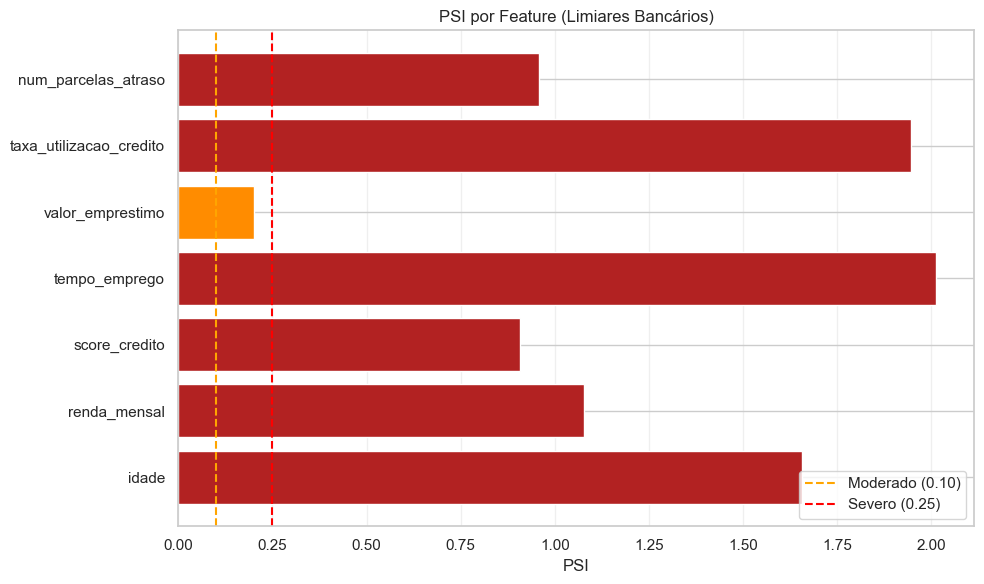

In [8]:
# Relatório completo com KS + PSI para gerar gráfico de barras PSI
report_psi = detector.detect_all(
    ref_data, prod_data, methods=["psi"]
)

fig = plot_psi_bars(report_psi, title="PSI por Feature (Limiares Bancários)")
plt.show()

## 4. Divergência Kullback-Leibler (KL)

> "A KL quantifica a perda de informação quando usamos Q no lugar de P.
> É sempre não-negativa e **não simétrica**."
>
> $$D_{KL}(P \| Q) = \sum_i P(i) \log \frac{P(i)}{Q(i)}$$
>
> — Seção *Saiba Mais — Divergência KL*, Documento da Aula 2
>
> Referência: Kullback, S., & Leibler, R. A. (1951).

In [9]:
# KL Divergence para todas as features numéricas
print(f"{'Feature':<30} {'KL(P||Q)':>12} {'KL(Q||P)':>12} {'Assimetria':>12}")
print("-" * 70)

for col in numerical_cols:
    kl_pq = detector.kl_divergence(
        ref_data[col].values, prod_data[col].values, feature_name=col
    )
    kl_qp = detector.kl_divergence(
        prod_data[col].values, ref_data[col].values, feature_name=col
    )
    assimetria = abs(kl_pq.statistic - kl_qp.statistic)
    print(f"{col:<30} {kl_pq.statistic:>12.4f} {kl_qp.statistic:>12.4f} {assimetria:>12.4f}")

print("\n💡 Note a assimetria da KL: D_KL(P||Q) ≠ D_KL(Q||P), conforme o Documento.")

Feature                            KL(P||Q)     KL(Q||P)   Assimetria
----------------------------------------------------------------------
idade                                1.1226       0.5347       0.5879
renda_mensal                         0.7491       0.3288       0.4203
score_credito                        0.3503       0.5568       0.2064
tempo_emprego                        1.4657       0.5473       0.9184
valor_emprestimo                     0.1158       0.0859       0.0299
taxa_utilizacao_credito              0.5723       1.3736       0.8013
num_parcelas_atraso                  0.3306       0.6277       0.2972

💡 Note a assimetria da KL: D_KL(P||Q) ≠ D_KL(Q||P), conforme o Documento.


## 5. Divergência Jensen-Shannon (JS)

> "A JS é uma variação simétrica e limitada da KL. Varia de 0 a 1 (usando log base 2)
> — oferecendo assim uma escala normalizada, mais intuitiva."
>
> $$D_{JS}(P \| Q) = \frac{1}{2} D_{KL}(P \| M) + \frac{1}{2} D_{KL}(Q \| M)$$
> onde $M = \frac{1}{2}(P + Q)$
>
> — Seção *Saiba Mais — Divergência JS*, Documento da Aula 2
>
> Referência: Lin, J. (1991).

In [10]:
# JS Divergence para todas as features numéricas
print(f"{'Feature':<30} {'JS Divergence':>15} {'JS Distance':>15} {'Drift?':>10}")
print("-" * 75)

for col in numerical_cols:
    result = detector.js_divergence(
        ref_data[col].values, prod_data[col].values, feature_name=col
    )
    js_distance = np.sqrt(result.statistic)  # raiz da JS = distância de JS
    symbol = "✓ SIM" if result.drift_detected else "✗ NÃO"
    print(f"{result.feature_name:<30} {result.statistic:>15.4f} {js_distance:>15.4f} {symbol:>10}")

print("\n💡 JS é simétrica e limitada entre 0 e 1, diferente da KL.")

Feature                          JS Divergence     JS Distance     Drift?
---------------------------------------------------------------------------
idade                                   0.1975          0.4444      ✓ SIM
renda_mensal                            0.1318          0.3630      ✓ SIM
score_credito                           0.1327          0.3643      ✓ SIM
tempo_emprego                           0.2081          0.4562      ✓ SIM
valor_emprestimo                        0.0334          0.1828      ✗ NÃO
taxa_utilizacao_credito                 0.2148          0.4635      ✓ SIM
num_parcelas_atraso                     0.1317          0.3629      ✓ SIM

💡 JS é simétrica e limitada entre 0 e 1, diferente da KL.


## 6. Teste Qui-quadrado (χ²) — Features Categóricas

> "O teste Qui-quadrado é aplicável para variáveis categóricas ou distribuições
> discretizadas em bins. Avalia se as frequências observadas em cada categoria
> diferem do esperado."
>
> — Seção *Testes estatísticos de hipóteses*, Documento da Aula 2
>
> Referência: Pearson, K. (1900).

In [11]:
# Teste Qui-quadrado para features categóricas
print(f"{'Feature':<30} {'χ²':>12} {'p-valor':>15} {'Drift?':>10}")
print("-" * 70)

for col in categorical_cols:
    result = detector.chi2_test(
        ref_data[col].values, prod_data[col].values, feature_name=col
    )
    symbol = "✓ SIM" if result.drift_detected else "✗ NÃO"
    p_str = f"{result.p_value:.3e}" if result.p_value is not None else "N/A"
    print(f"{result.feature_name:<30} {result.statistic:>12.4f} {p_str:>15} {symbol:>10}")

Feature                                  χ²         p-valor     Drift?
----------------------------------------------------------------------
tipo_residencia                   2093.3138       0.000e+00      ✓ SIM
categoria_risco                   1660.5917       0.000e+00      ✓ SIM


## 7. Análise Comparativa de Todos os Métodos

> "Na prática, métricas de divergência e testes de hipótese se complementam.
> As métricas dizem *quanto* drift ocorreu; os testes dizem se podemos afirmar
> com confiança que o drift não é apenas ruído aleatório."
>
> — Seção *Saiba Mais*, Documento da Aula 2

In [12]:
# Relatório completo com todos os métodos
report_full = detector.detect_all(
    ref_data, prod_data,
    methods=["ks", "psi", "kl", "js"],
)

# Tabela resumo
summary_df = generate_drift_summary(report_full)
print(f"Total de features analisadas: {report_full.n_features_total}")
print(f"Features com drift detectado: {report_full.n_features_drifted}")
print(f"Features afetadas: {report_full.drifted_features}")
print()
display(summary_df)

Total de features analisadas: 9
Features com drift detectado: 9
Features afetadas: ['categoria_risco', 'idade', 'num_parcelas_atraso', 'renda_mensal', 'score_credito', 'taxa_utilizacao_credito', 'tempo_emprego', 'tipo_residencia', 'valor_emprestimo']



,feature,method,statistic,p_value,threshold,drift_detected
0,idade,ks,0.434400,0.000000e+00,0.05,True
1,idade,psi,1.657291,NaN,0.25,True
2,idade,kl,1.122595,NaN,0.10,True
3,idade,js,0.197533,NaN,0.05,True
4,renda_mensal,ks,0.337000,6.628289e-252,0.05,True
5,renda_mensal,psi,1.077846,NaN,0.25,True
6,renda_mensal,kl,0.749053,NaN,0.10,True
7,renda_mensal,js,0.131761,NaN,0.05,True
8,score_credito,ks,0.357600,2.536251e-284,0.05,True
9,score_credito,psi,0.907121,NaN,0.25,True


### 7.1 Heatmap de Drift (Features × Métodos)

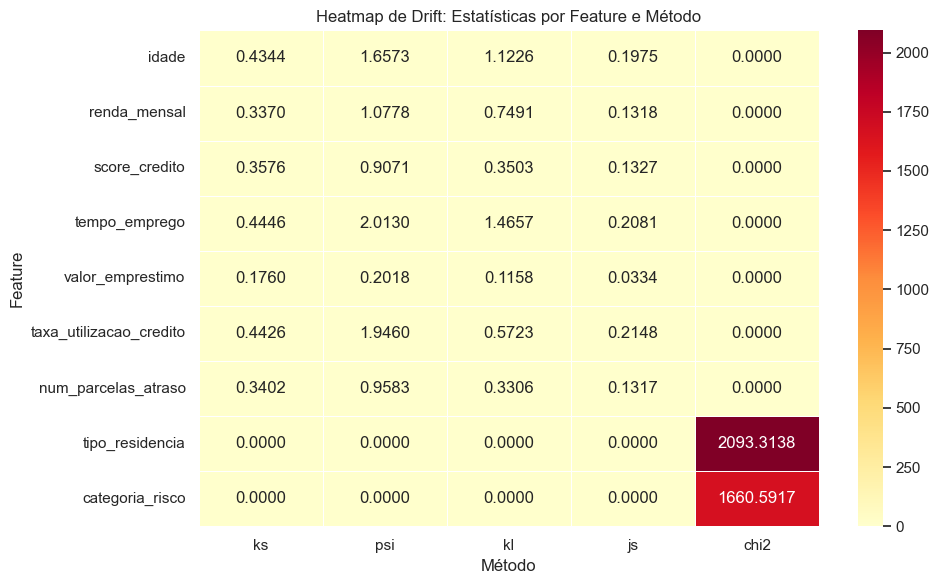

In [13]:
# Heatmap de estatísticas de drift
fig = plot_drift_heatmap(
    report_full,
    metric="statistic",
    title="Heatmap de Drift: Estatísticas por Feature e Método",
)
plt.show()

### 7.2 Distribuições das Features com Maior Drift

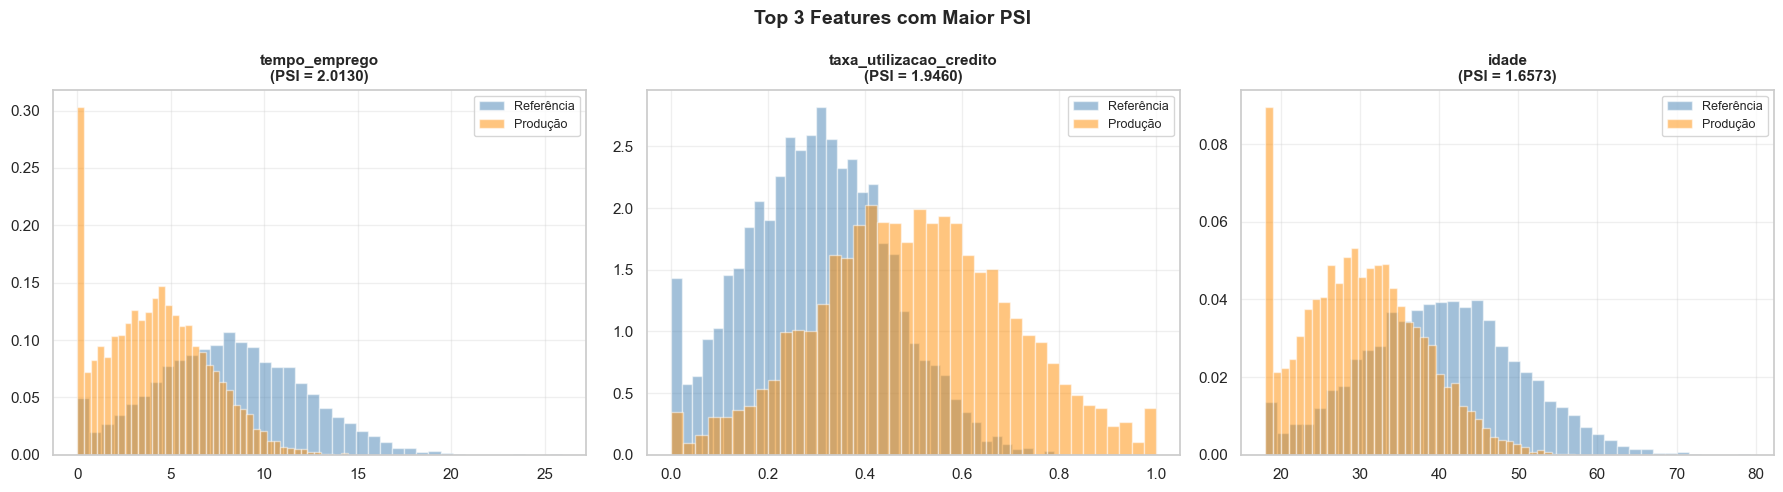

In [14]:
# Visualização de distribuição das top 3 features com maior PSI
psi_results = [(r.feature_name, r.statistic) for r in report_full.results if r.method == "psi"]
psi_results.sort(key=lambda x: x[1], reverse=True)

top_features = [f for f, _ in psi_results[:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, top_features):
    fig_comp = plot_distribution_comparison(
        ref_data[col].values, prod_data[col].values,
        feature_name=col,
    )
    plt.close(fig_comp)  # fechamos para redesenhar no subplot

    ax.hist(ref_data[col].dropna(), bins=40, alpha=0.5, density=True,
            label="Referência", color="steelblue", edgecolor="white")
    ax.hist(prod_data[col].dropna(), bins=40, alpha=0.5, density=True,
            label="Produção", color="darkorange", edgecolor="white")
    ax.set_title(f"{col}\n(PSI = {dict(psi_results)[col]:.4f})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Top 3 Features com Maior PSI", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Resumo

Neste notebook, implementamos e aplicamos os principais métodos de detecção de drift:

| Método | Tipo | Resultado |
|--------|------|----------|
| **KS Test** | Teste de hipótese (contínuas) | p-valor indica significância |
| **PSI** | Métrica de estabilidade | Score 0–∞ com limiares bancários |
| **KL Divergence** | Métrica de informação | Assimétrica, não limitada |
| **JS Divergence** | Métrica de informação | Simétrica, limitada [0, 1] |
| **Qui-quadrado** | Teste de hipótese (categóricas) | p-valor indica significância |

Confirmamos estatisticamente o drift visual observado no Notebook 1, com múltiplas
features apresentando drift significativo em todos os métodos.

No **Notebook 3**, construiremos um **pipeline automatizado** de monitoramento de drift.

---

**Próximo:** [03_avaliacao.ipynb](03_avaliacao.ipynb) — Pipeline Automatizado com Evidently/NannyML